### Final Project - Sentiment Analysis on Financial Data

About the project

Objective:

The goal of this project is to build and compare several Natural Language Processing (NLP) models to classify the sentiment of short financial news headlines as negative, neutral, or positive. Sentiment classification helps identify market tone, investor reactions, and directional implications in financial texts. 

Github Repo - https://github.com/Guche20/MSDS/blob/Week-5-Project-DeepLearning/week-5-project.ipynb

Dataset Information:

Datasource - https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news/data

TThe dataset consists of short financial news headlines paired with sentiment labels. Each row contains:

text: a headline from a financial news source

sentiment: the corresponding sentiment label (negative, neutral, or positive)

Since the CSV does not include headers, the dataset was manually assigned the column names text and sentiment. Labels were then mapped to numerical values for model training.


Files included:
- CSV file with > 4000 rows and 2 columns:
    - text - the financial news headline
    - sentiment - negative, neutral, positive



In [ ]:
# %pip install chardet


     -------------------------------------- 199.4/199.4 KB 4.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\godsw\Documents\wk_4\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [59]:
# %pip install pandas scikit-learn matplotlib numpy nltk

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV


In [34]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Embedding, GlobalAveragePooling1D,
                                     Conv1D, GlobalMaxPooling1D,
                                     Bidirectional, LSTM, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#Identify file encoding
import chardet

with open("Final-Project/all-data.csv", "rb") as f:
    print(chardet.detect(f.read()))


{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


Loading the data

In [40]:
#Load file into dataframe with correct encoding 

# df = pd.read_csv("Final-Project/all-data.csv", encoding='utf-8', errors='replace')

df = pd.read_csv("Final-Project/all-data.csv", header=None, encoding='cp1252')

df.head()


,0,1
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [41]:
#dataset does not have column names, so I will add them

df.columns = ["sentiment", "text"]
df.head()

,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


#### Exploratory Data Analysis & Data Preprocessing

Handling missing data and duplicates

In [42]:
print("Missing in text:", df['text'].isna().sum())
print("Missing in sentiment:", df['sentiment'].isna().sum())

# Drop rows with missing text or sentiment
df = df.dropna(subset=['text', 'sentiment'])

# Drop exact duplicate rows
df = df.drop_duplicates(subset=['text', 'sentiment']).reset_index(drop=True)

df.shape


Missing in text: 0
Missing in sentiment: 0


(4840, 2)

Converting Sentiment column to binary labels

In [43]:
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_mapping)


Plotting label histograms

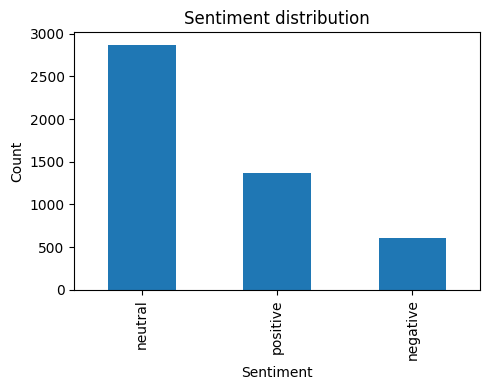

In [44]:
label_counts = df['sentiment'].value_counts()

plt.figure(figsize=(5,4))
label_counts.plot(kind='bar')
plt.title("Sentiment distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Checking text length

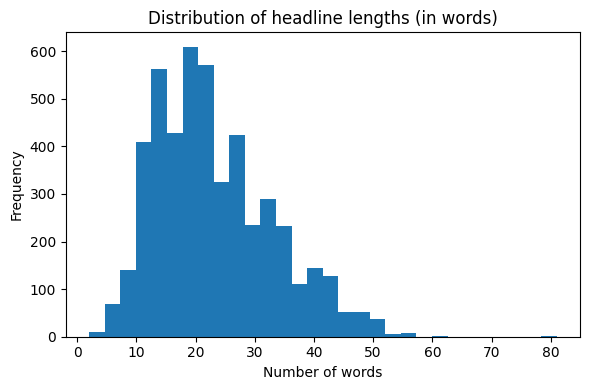

count    4840.000000
mean       23.092975
std         9.940827
min         2.000000
25%        16.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: text_len, dtype: float64

In [45]:
df['text_len'] = df['text'].str.split().apply(len)

plt.figure(figsize=(6,4))
plt.hist(df['text_len'], bins=30)
plt.title("Distribution of headline lengths (in words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

df['text_len'].describe()


Doing some simple cleaning on the text, but not too much to significantly change the context or structure

In [46]:
def simple_clean(text):
    if not isinstance(text, str):
        return ""
    text = text.strip().lower()
    return text

df['clean_text'] = df['text'].apply(simple_clean)


In [47]:
df.head()

,sentiment,text,label,text_len,clean_text
0,neutral,"According to Gran , the company has no plans t...",1,25,"according to gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...,1,31,technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...,0,36,the international electronic industry company ...
3,positive,With the new production plant the company woul...,2,33,with the new production plant the company woul...
4,positive,According to the company 's updated strategy f...,2,41,according to the company 's updated strategy f...


#### Modelling Plan

Following the EDA, I intend to do the following:

- Create tokens for the words
- Creating 4 architectures - AvgEmbed_small, AvgEmbed_big, CNN_64, BiLSTM_64
- For performance measurement, I will utilize Accuracy and F1 in case of class imbalance

Train/Test Split

In [48]:
X = df['clean_text'].values
y = df['label'].values

X_train_full, X_val, y_train_full, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

len(X_train_full), len(X_val)
 

(3872, 968)

In [49]:
# Diagnostic: show columns and the raw repr of each one
print("Shape:", df.shape)
print("Columns list:", df.columns.tolist())
for c in df.columns:
    print("Column repr:", repr(c))
display(df.head())

Shape: (4840, 5)
Columns list: ['sentiment', 'text', 'label', 'text_len', 'clean_text']
Column repr: 'sentiment'
Column repr: 'text'
Column repr: 'label'
Column repr: 'text_len'
Column repr: 'clean_text'


,sentiment,text,label,text_len,clean_text
0,neutral,"According to Gran , the company has no plans t...",1,25,"according to gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...,1,31,technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...,0,36,the international electronic industry company ...
3,positive,With the new production plant the company woul...,2,33,with the new production plant the company woul...
4,positive,According to the company 's updated strategy f...,2,41,according to the company 's updated strategy f...


In [50]:
# Inspect data size and structure
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
print(df.info())

print("\nClass distribution:")
print(df['sentiment'].value_counts())


Shape: (4840, 5)

Columns: ['sentiment', 'text', 'label', 'text_len', 'clean_text']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4840 entries, 0 to 4839
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sentiment   4840 non-null   object
 1   text        4840 non-null   object
 2   label       4840 non-null   int64 
 3   text_len    4840 non-null   int64 
 4   clean_text  4840 non-null   object
dtypes: int64(2), object(3)
memory usage: 189.2+ KB
None

Class distribution:
sentiment
neutral     2873
positive    1363
negative     604
Name: count, dtype: int64


Training with subset of size 3000

In [51]:
SUBSET_SIZE = 3000

if len(X_train_full) > SUBSET_SIZE:
    # choose a random subset
    idx = np.random.choice(len(X_train_full), size=SUBSET_SIZE, replace=False)
    X_train = X_train_full[idx]
    y_train = y_train_full[idx]
else:
    X_train = X_train_full
    y_train = y_train_full

len(X_train)


3000

<!-- Buidling TF-IDF -->

In [39]:
# tfidf = TfidfVectorizer(
#     max_features=10000,      
#     ngram_range=(1, 2),      
#     min_df=2                 
# )

# X_train_tfidf = tfidf.fit_transform(X_train)
# X_val_tfidf   = tfidf.transform(X_val)

# X_train_tfidf.shape, X_val_tfidf.shape


Creating tokens

In [52]:
MAX_NUM_WORDS = 20000   
MAX_SEQ_LEN   = 40      

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)
vocab_size


7737

In [53]:
num_classes = 3
BATCH_SIZE = 64
EPOCHS = 10  # we’ll use early stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


#### Model Architectures

I will be building 3 models:

- Model A: AvgEmbed_small

- Model B: AvgEmbed_big

- Model C: CNN_64

- Model D: BiLSTM_64



AvgEmbed_small

This model is fast and simple and forms a good baseline for training. It does have some risk of underfitting as it requires lower capacity

In [54]:
def build_avgembed_model(embed_dim=50):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=MAX_SEQ_LEN),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_avg_small = build_avgembed_model(embed_dim=50)  
model_avg_small.summary()


c:\Users\godsw\Documents\wk_4\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

AvgEmbed_big

This model has more capacity but can be slower and has a risk of overfitting.

In [55]:
model_avg_big = build_avgembed_model(embed_dim=200)    # "big"
model_avg_big.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

CNN_64

This is model's aptitude is in capturing local word patterns as well as having good accuracy with short text.

In [56]:
def build_cnn_model():
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=100,
                  input_length=MAX_SEQ_LEN),
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_cnn_64 = build_cnn_model()
model_cnn_64.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

BiLSTM_64

This model can be the best at capturing longer text but it can be quite slow.

In [57]:
def build_bilstm_model():
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=100,
                  input_length=MAX_SEQ_LEN),
        Bidirectional(LSTM(64)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_bilstm_64 = build_bilstm_model()
model_bilstm_64.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training all models

In [63]:
models = {
    "AvgEmbed_small": model_avg_small,
    "AvgEmbed_big":   model_avg_big,
    "CNN_64":         model_cnn_64,
    "BiLSTM_64":      model_bilstm_64
}

histories = {}
results = []

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )
    histories[name] = history
    
    # Evaluate
    val_probs = model.predict(X_val_pad, verbose=0)
    val_pred = np.argmax(val_probs, axis=1)
    
    acc = accuracy_score(y_val, val_pred)
    macro_f1 = f1_score(y_val, val_pred, average='macro')
    
    print(f"{name} - Val Accuracy: {acc:.4f}, Macro F1: {macro_f1:.4f}")
    
    results.append({
        "Model": name,
        "Val_Accuracy": acc,
        "Val_MacroF1": macro_f1
    })



=== Training AvgEmbed_small ===
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9547 - loss: 0.1629 - val_accuracy: 0.7469 - val_loss: 0.6853
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9643 - loss: 0.1368 - val_accuracy: 0.7531 - val_loss: 0.6926
AvgEmbed_small - Val Accuracy: 0.7469, Macro F1: 0.6724

=== Training AvgEmbed_big ===
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6600 - loss: 0.7695 - val_accuracy: 0.6756 - val_loss: 0.7483
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7530 - loss: 0.6183 - val_accuracy: 0.7035 - val_loss: 0.6719
AvgEmbed_big - Val Accuracy: 0.6756, Macro F1: 0.4525

=== Training CNN_64 ===
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9827 - loss: 0.0924 - val_accuracy: 0.7624 - val_loss: 0.7045
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9940 - loss: 0.0422 - val_accuracy: 0.7707 - val_loss: 0.7438
CNN_64 - Val Accuracy: 0.7624, Macro F1:

Results table

In [64]:
results_df = pd.DataFrame(results)
results_df


,Model,Val_Accuracy,Val_MacroF1
0,AvgEmbed_small,0.746901,0.672360
1,AvgEmbed_big,0.675620,0.452516
2,CNN_64,0.762397,0.699952
3,BiLSTM_64,0.699380,0.530568


Plotting results for all 4 models

In [65]:

def plot_history(history, title):
    """Plot train/val loss and accuracy for a single model."""
    hist = history.history

    # Some TF versions use 'accuracy', some 'acc'
    acc_key = 'accuracy' if 'accuracy' in hist else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in hist else 'val_acc'

    epochs = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist['loss'], label='Train')
    plt.plot(epochs, hist['val_loss'], label='Val')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist[acc_key], label='Train')
    plt.plot(epochs, hist[val_acc_key], label='Val')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


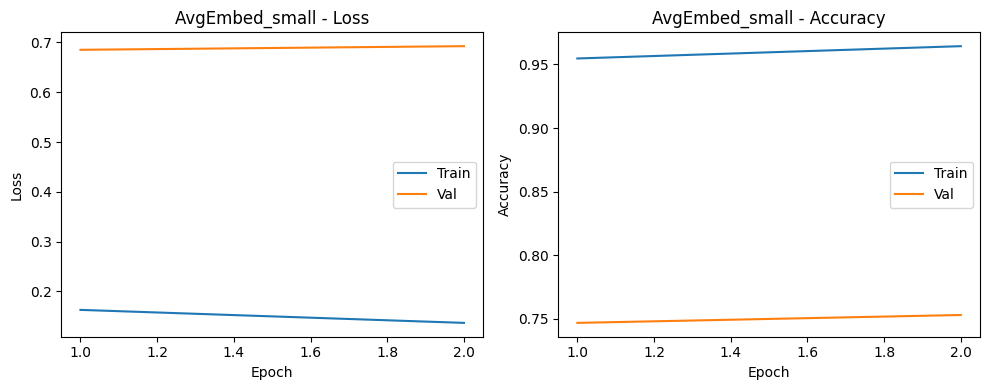

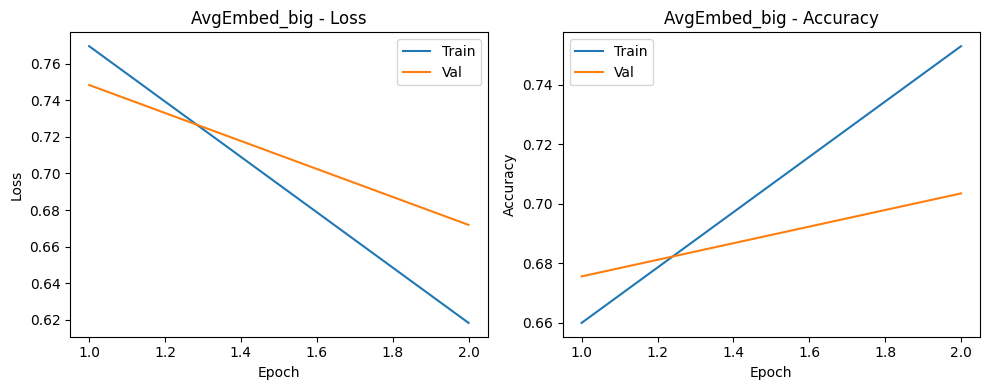

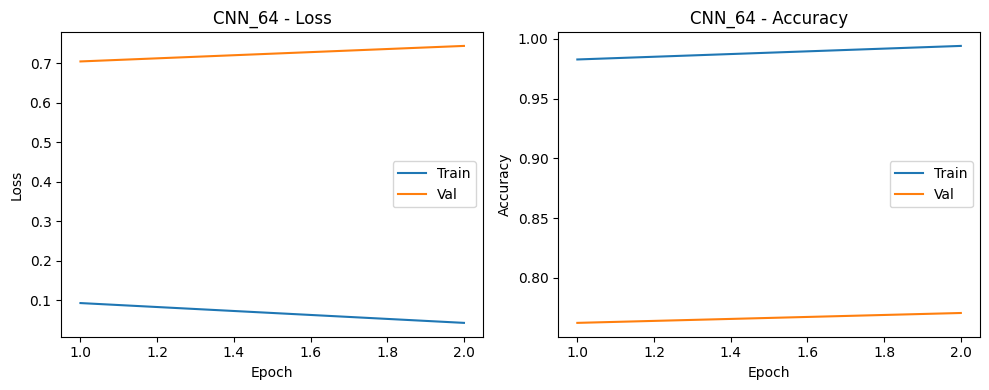

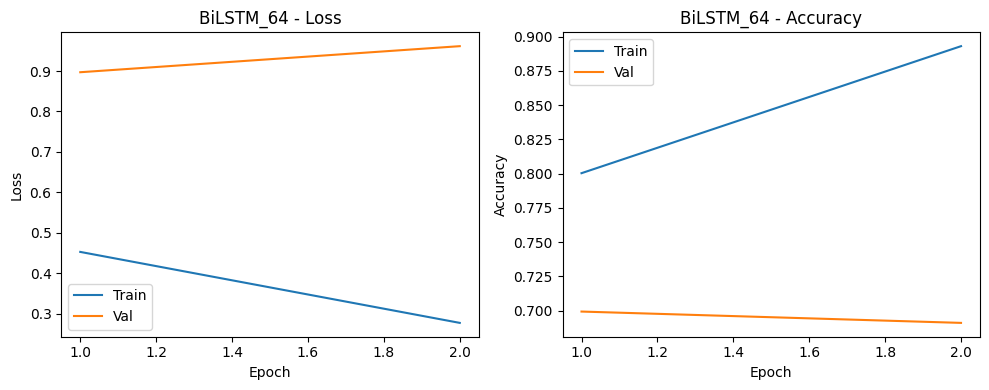

In [66]:
for name, history in histories.items():
    plot_history(history, title=name)


Results and Analysis

In [68]:
#printing results_df
results_df

,Model,Val_Accuracy,Val_MacroF1
0,AvgEmbed_small,0.746901,0.672360
1,AvgEmbed_big,0.675620,0.452516
2,CNN_64,0.762397,0.699952
3,BiLSTM_64,0.699380,0.530568


In [69]:
# Identify best model
best_name = results_df.sort_values("Val_MacroF1", ascending=False).iloc[0]["Model"]
best_model = models[best_name]

val_probs = best_model.predict(X_val_pad)
val_pred = np.argmax(val_probs, axis=1)

print("Best model:", best_name)
print("\nClassification Report:\n", classification_report(y_val, val_pred))


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Best model: CNN_64

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.59      0.62       121
           1       0.79      0.89      0.84       575
           2       0.72      0.57      0.64       272

    accuracy                           0.76       968
   macro avg       0.73      0.68      0.70       968
weighted avg       0.76      0.76      0.76       968



31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


<Figure size 600x600 with 0 Axes>

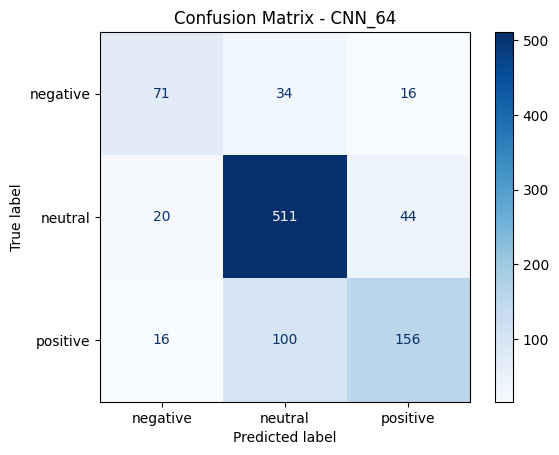

In [70]:
#Creating Confusion Matrix for the best model
val_probs = best_model.predict(X_val_pad)
val_pred = np.argmax(val_probs, axis=1)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["negative", "neutral", "positive"])

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()


Model comparison

- CNN_64 achieved the best overall performance with a validation accuracy of about 76% and macro-F1 of about 0.70. This suggests that 1D convolutions with 64 filters and global max-pooling are effective at capturing local n-gram patterns.

- AvgEmbed_small performed well, reaching ~75% accuracy and macro-F1 of 0.67, only slightly below CNN_64, while being the simplest and lightest model. 

- AvgEmbed_big and BiLSTM_64 underperformed relative to CNN_64 and AvgEmbed_small, with accuracy ~68%, macro-F1 ~0.45 and accuracy 70%, macro-F1 0.53 respectively.


Hyperparameter and training choices

- All models used the same preprocessing pipeline (tokenization + padding), the same maximum sequence length, and the same number of classes, making the comparison fair.

- I varied the embedding dimension for the AvgEmbed models (small vs big) and the architecture type (average pooling vs CNN vs BiLSTM), which effectively acts as a form of architecture-level hyperparameter tuning.

#### Conclusion

In this project, I compared four neural architectures for financial sentiment analysis: AvgEmbed_small, AvgEmbed_big, CNN_64, and BiLSTM_64. The CNN_64 model performed best, achieving the highest validation accuracy and macro-F1, showing that local word patterns (n-grams) are very effective for short financial headlines. The AvgEmbed_small model also performed strongly, offering competitive results with very low complexity.

In contrast, AvgEmbed_big and BiLSTM_64 underperformed, likely due to limited training data and higher model capacity, which led to overfitting. Overall, the results show that simpler architectures can outperform more complex ones when data size is modest.

Future improvements include training on the full dataset, using pretrained embeddings or transformer-based models such as FinBERT, and performing more extensive hyperparameter tuning to further improve performance.